# Projekt ML – przewidywanie ocen filmów IMDb

Notebook ma cały pipeline na danych Top 1000 filmów z IMDb. W drugiej części dorzucam jeszcze IMDB 5000 z Kaggle. Cel to przewidzieć ocenę IMDb na podstawie cech filmu (liczba głosów, gatunek, długość, przychody itd).

## 1. Import bibliotek

Standardowy zestaw – pandas do tabel, numpy do liczb, matplotlib i seaborn do wykresów. seaborn ustawiam na jasny styl bo ciemny mi nie pasował.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Wczytanie danych

`read_csv` wczytuje plik CSV do DataFrame. `head()` pokazuje pierwsze 5 wierszy żeby zobaczyć co tam jest.

In [2]:
df = pd.read_csv('imdb_top_1000.csv')
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## 3. Rozmiar datasetu

Sprawdzam ile mam wierszy i kolumn.

In [3]:
df.shape

(1000, 16)

## 4. Info o kolumnach

`info()` pokazuje typ każdej kolumny i ile jest wartości niepustych. object = tekst, float64 = liczba z przecinkiem, int64 = całkowita.

Tam gdzie Non-Null Count jest mniejszy niż liczba wierszy, są braki – tym zajmę się później.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


## 5. Statystyki opisowe

`describe()` daje średnią, odchylenie, min, max i kwartyle dla kolumn numerycznych.

In [5]:
df.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


## 6. Braki danych

`isnull().sum()` liczy ile NaN-ów w każdej kolumnie. Zero = brak braków.

In [6]:
df.isnull().sum()

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

## 7. Lista kolumn

Wszystkie nazwy kolumn w datasecie.

In [7]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

---
## EDA

Patrzę na dane przed budową modelu.

### Wykres 1 – rozkład ocen

Histogram pokazuje jak rozkładają się oceny w datasecie. `kde=True` dorysowuje krzywą wygładzającą.

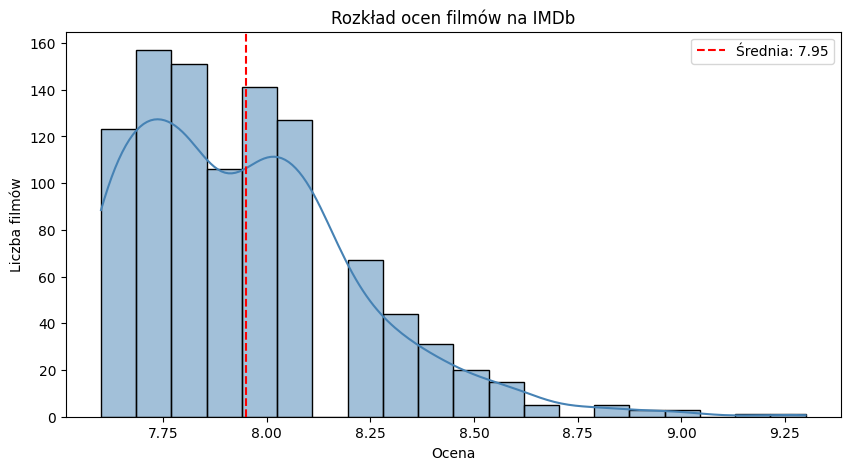

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df['IMDB_Rating'], bins=20, kde=True, color='steelblue')
plt.title('Rozkład ocen filmów na IMDb')
plt.xlabel('Ocena')
plt.ylabel('Liczba filmów')
plt.axvline(df['IMDB_Rating'].mean(), color='red', linestyle='--', label=f"Średnia: {df['IMDB_Rating'].mean():.2f}")
plt.legend()
plt.show()

### Wykres 2 – ocena vs liczba głosów

Scatter plot, każdy punkt to jeden film. Skala logarytmiczna na X bo liczba głosów waha się od kilkudziesięciu tysięcy do ponad 2 milionów, więc bez skali log wszystko zlałoby się po lewej stronie.

Cały dataset to Top 1000, więc oceny są w przedziale 7.6-9.3.

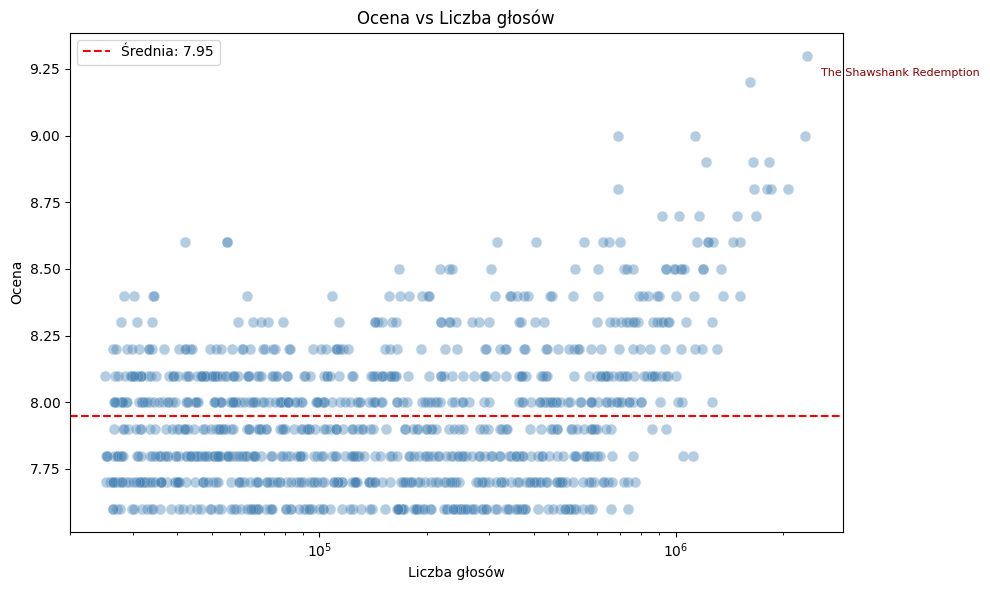

In [9]:
plt.figure(figsize=(10,6))
df['No_of_Votes'] = pd.to_numeric(df['No_of_Votes'], errors='coerce')
plt.scatter(df['No_of_Votes'], df['IMDB_Rating'], alpha=0.4, color='steelblue', edgecolors='white', linewidths=0.3, s=60)
plt.xscale('log')
plt.title('Ocena vs Liczba głosów')
plt.xlabel('Liczba głosów')
plt.ylabel('Ocena')
mean_rating = df['IMDB_Rating'].mean()
plt.axhline(mean_rating, color='red', linestyle='--', label=f"Średnia: {mean_rating:.2f}")
best = df.loc[df['IMDB_Rating'].idxmax()]
plt.annotate(best['Series_Title'],
             xy=(best['No_of_Votes'], best['IMDB_Rating']),
             xytext=(10, -15), textcoords='offset points', fontsize=8, color='darkred')
plt.legend()
plt.tight_layout()
plt.show()

---
## Preprocessing

### Krok 1 – jeszcze raz braki

Wcześniej widać było że Meta_score ma 157 braków, Gross 169.

In [10]:
df.isnull().sum()

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

### Krok 2 – uzupełnienie braków

Można albo wyrzucić wiersze z brakami, albo coś podstawić. Wybieram medianę bo jest odporna na outliery.

`fillna(mediana)` podstawia medianę za każdy NaN. Po tym braki powinny być zerowe.

In [11]:
df['Meta_score'] = df['Meta_score'].fillna(df['Meta_score'].median())
df['Gross'] = df['Gross'].fillna(df['Gross'].median())

df[['Meta_score', 'Gross']].isnull().sum()

Meta_score    0
Gross         0
dtype: int64

### Krok 3 – czyszczenie kolumn

Runtime jest jako "142 min", trzeba wyciąć " min" i zamienić na liczbę. Gross ma przecinki ("28,341,469") więc je usuwam.

`if dtype == object` sprawdza czy kolumna jest tekstem. Bez tego po ponownym uruchomieniu komórki byłby błąd bo nie da się odejmować stringa od liczby.

In [12]:
if df['Gross'].dtype == object:
    df['Gross'] = df['Gross'].str.replace(',', '').astype(float)
df['Gross'] = df['Gross'].fillna(df['Gross'].median())

if df['Runtime'].dtype == object:
    df['Runtime'] = df['Runtime'].str.replace(' min', '').astype(int)

df[['Runtime', 'Gross', 'No_of_Votes']].head()

,Runtime,Gross,No_of_Votes
0,142,28341469.0,2343110
1,175,134966411.0,1620367
2,152,534858444.0,2303232
3,202,57300000.0,1129952
4,96,4360000.0,689845


### Krok 4 – feature engineering

Genre to tekst typu "Drama, Crime". Model nie radzi sobie z tekstem, potrzebuje liczb.

Robię one-hot encoding – dla każdego gatunku osobna kolumna z 0/1. Np. `is_Drama=1` jeśli film jest dramatem.

In [13]:
top_genres = ['Drama', 'Action', 'Comedy', 'Crime', 'Adventure', 'Biography']

for genre in top_genres:
    df[f'is_{genre}'] = df['Genre'].str.contains(genre, na=False).astype(int)

df[['Genre'] + [f'is_{g}' for g in top_genres]].head()

,Genre,is_Drama,is_Action,is_Comedy,is_Crime,is_Adventure,is_Biography
0,Drama,1,0,0,0,0,0
1,"Crime, Drama",1,0,0,1,0,0
2,"Action, Crime, Drama",1,1,0,1,0,0
3,"Crime, Drama",1,0,0,1,0,0
4,"Crime, Drama",1,0,0,1,0,0


### Krok 5 – train/test split

Standardowy podział 80/20. Model uczy się na 80%, testuję na 20% ktoer nie widział.

`random_state=42` żeby wyniki były powtarzalne.

In [14]:
from sklearn.model_selection import train_test_split

features = ['No_of_Votes', 'Meta_score', 'Runtime', 'Gross'] + [f'is_{g}' for g in top_genres]

X = df[features]
y = df['IMDB_Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dane treningowe: {X_train.shape}")
print(f"Dane testowe: {X_test.shape}")

Dane treningowe: (800, 10)
Dane testowe: (200, 10)


## Budowa modeli

Buduję dwa modele i porównuję.

### Model 1 – regresja liniowa

Najprostszy. Zakłada że zależność cechy od oceny to prosta linia.

### Model 2 – Random Forest

100 drzew decyzyjnych, każde uczy się trochę inaczej, na końcu predykcje są uśredniane. Mocniejszy bo łapie nieliniowe zależności.

### Metryki

RMSE – średni błąd. Mniejszy = lepiej.
R² – jaki procent zmienności model wyjaśnia. 0-1, większy = lepiej.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Regresja Liniowa ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.3f}")
print(f"R^2: {r2_score(y_test, y_pred_lr):.3f}")

print("\n=== Random Forest ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")
print(f"R^2: {r2_score(y_test, y_pred_rf):.3f}")

=== Regresja Liniowa ===
RMSE: 0.218
R^2: 0.260

=== Random Forest ===
RMSE: 0.193
R^2: 0.421


## Wykresy – przewidywane vs rzeczywiste

Każdy punkt to jeden film z testu. Oś X – rzeczywista ocena, Y – przewidywana. Czerwona linia to idealna predykcja.

Im bliżej linii tym lepszy model.

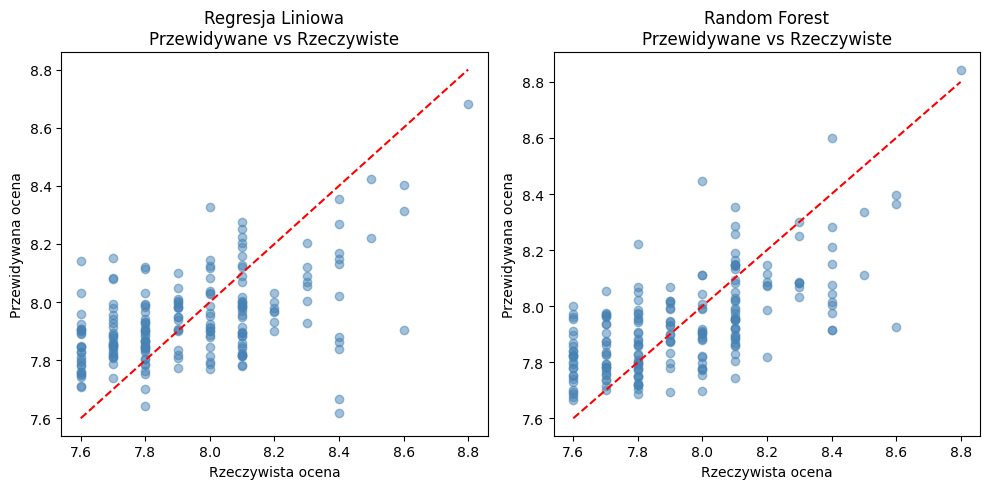

In [16]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Regresja Liniowa\nPrzewidywane vs Rzeczywiste')
plt.xlabel('Rzeczywista ocena')
plt.ylabel('Przewidywana ocena')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest\nPrzewidywane vs Rzeczywiste')
plt.xlabel('Rzeczywista ocena')
plt.ylabel('Przewidywana ocena')

plt.tight_layout()
plt.show()

---
## Podsumowanie cz. 1

Po kolei: wczytanie danych, EDA, czyszczenie i uzupełnienie braków, one-hot encoding gatunkow, train/test split, regresja liniowa + Random Forest, RMSE i R², wykresy.

Random Forest wyszedł lepszy od regresji ale dalej R² ~0.41 to nie jest super wynik. W kolejnej części dorzucam więcej cech i probuję mocniejszych modeli.

---
## 2. Feature Importance

Mam model ale nie wiem co go napędza. Random Forest ma to wbudowane.

`rf.feature_importances_` zwraca wagę dla każdej cechy. Suma = 1, większa wartość = ważniejsza cecha.

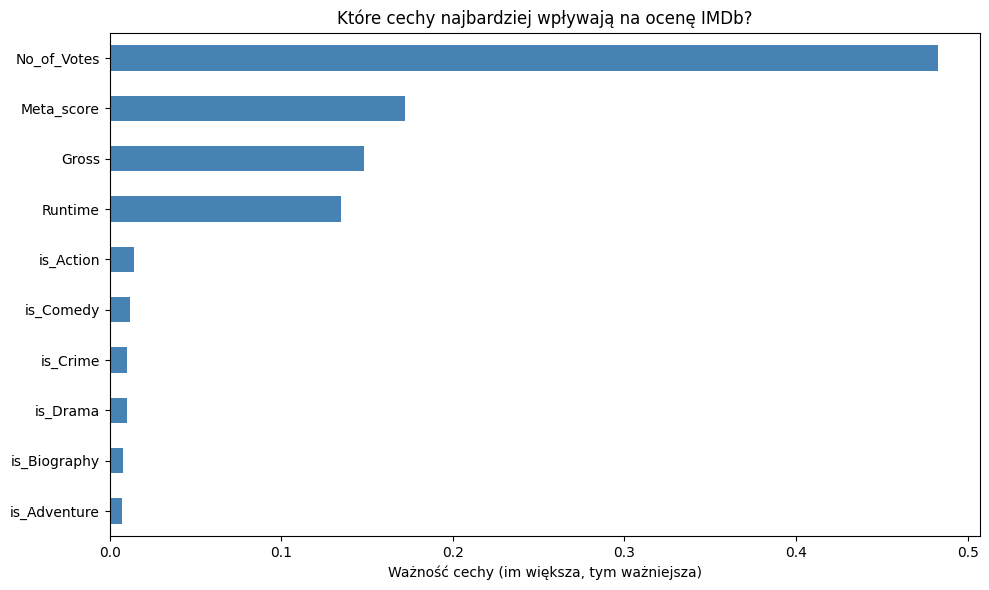


Ranking cech:
 No_of_Votes: 0.483
 Meta_score: 0.172
 Gross: 0.148
 Runtime: 0.135
 is_Action: 0.014
 is_Comedy: 0.012
 is_Crime: 0.010
 is_Drama: 0.010
 is_Biography: 0.008
 is_Adventure: 0.007


In [17]:
importances = pd.Series(rf.feature_importances_, index=features)
importances_sorted = importances.sort_values()

plt.figure(figsize=(10, 6))
importances_sorted.plot(kind='barh', color='steelblue')
plt.title('Które cechy najbardziej wpływają na ocenę IMDb?')
plt.xlabel('Ważność cechy (im większa, tym ważniejsza)')
plt.tight_layout()
plt.show()

print('\nRanking cech:')
for feat, imp in importances.sort_values(ascending=False).items():
    print(f" {feat}: {imp:.3f}")

---
## 3. Nowe cechy – feature engineering v2

### Cecha 1 – rok premiery

Rok może być istotny. Stare filmy w datasecie to klasyki bo przetrwały test czasu. Nowsze są mieszanką wszystkiego.

`to_numeric(errors='coerce')` zamienia cokolwiek się nie da skonwertować na NaN. Potem fillna medianą.

In [18]:
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')
df['Released_Year'] = df['Released_Year'].fillna(df['Released_Year'].median())

print(f"Rok min: {df['Released_Year'].min()}, max: {df['Released_Year'].max()}")
print(f"Braki uzupełnione, typ: {df['Released_Year'].dtype}")

Rok min: 1920.0, max: 2020.0
Braki uzupełnione, typ: float64


### Cecha 2 – reżyser

600+ kolumn dla każdego reżysera to za dużo. Robię prościej – cecha binarna `is_top_director` dla 20 najczęściej pojawiających się.

In [19]:
print("Top 15 rezyserow:")
print(df['Director'].value_counts().head(15))

top_directors = df['Director'].value_counts().head(20).index
df['is_top_director'] = df['Director'].isin(top_directors).astype(int)

print(f"\nFilmy z top rezyserem: {df['is_top_director'].sum()}")
print(f"Procent: {df['is_top_director'].mean()*100:.1f}%")

Top 15 reżyserów w datasecie:
Director
Alfred Hitchcock     14
Steven Spielberg     13
Hayao Miyazaki       11
Akira Kurosawa       10
Martin Scorsese      10
Woody Allen           9
Stanley Kubrick       9
Billy Wilder          9
Clint Eastwood        8
Christopher Nolan     8
David Fincher         8
Quentin Tarantino     8
Howard Hawks          7
Rob Reiner            7
Ingmar Bergman        7
Name: count, dtype: int64

Filmy z top reżyserem: 168
Procent datasetu: 16.8%


### Sprawdzam czy cecha ma sens

Zanim wepchnę cechę do modelu, patrzę czy w danych jest w ogóle jakaś różnica.

Średnia ocena top reżyserów vs reszta.

In [20]:
print(f"Srednia ocena - top rezyserzy: {df[df['is_top_director']==1]['IMDB_Rating'].mean():.2f}")
print(f"Srednia ocena - pozostali: {df[df['is_top_director']==0]['IMDB_Rating'].mean():.2f}")

Średnia ocena - top reżyserzy: 8.06
Średnia ocena - pozostali: 7.93


### Trenuję model v2

Te same parametry Random Forest co wcześniej, tylko więcej cech (rok i reżyser).

Porównuję v1 vs v2.

In [21]:
features_v2 = ['No_of_Votes', 'Meta_score', 'Runtime', 'Gross', 'Released_Year', 'is_top_director'] + [f'is_{g}' for g in top_genres]

X_v2 = df[features_v2]
y_v2 = df['IMDB_Rating']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

rf_v2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_v2.fit(X_train_v2, y_train_v2)
y_pred_v2 = rf_v2.predict(X_test_v2)

print("Porównanie modeli")
print(f"RF v1 (bez roku i reżysera): RMSE={np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}, R^2={r2_score(y_test, y_pred_rf):.3f}")
print(f"RF v1 (z rokiem i reżyserem): RMSE={np.sqrt(mean_squared_error(y_test_v2, y_pred_v2)):.3f}, R^2={r2_score(y_test_v2, y_pred_v2):.3f}")

Porównanie modeli
RF v1 (bez roku i reżysera): RMSE=0.193, R^2=0.421
RF v1 (z rokiem i reżyserem): RMSE=0.187, R^2=0.455


---
## 4. XGBoost

Random Forest = 100 drzew niezależnych, predykcje uśredniane.
XGBoost = drzewa sekwencyjne, każde poprawia błędy poprzedniego (boosting).

Parametry:
- n_estimators=100, czyli 100 drzew
- learning_rate=0.1, jak szybko się uczy
- max_depth=4, max głębokość drzew

In [22]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    verbosity=0
)

xgb.fit(X_train_v2, y_train_v2)
y_pred_xgb = xgb.predict(X_test_v2)

print("Porównanie wszystkich modeli")
print(f"Regresja Liniowa RMSE={np.sqrt(mean_squared_error(y_test, y_pred_lr)):.3f}, R^2={r2_score(y_test, y_pred_lr):.3f}")
print(f"Random Forest v1 RMSE={np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}, R^2={r2_score(y_test, y_pred_rf):.3f}")
print(f"Random Forest v2 RMSE={np.sqrt(mean_squared_error(y_test_v2, y_pred_v2)):.3f}, R^2={r2_score(y_test_v2, y_pred_v2):.3f}")
print(f"XGBoost RMSE={np.sqrt(mean_squared_error(y_test_v2, y_pred_xgb)):.3f}, R^2={r2_score(y_test_v2, y_pred_xgb):.3f}")


Porównanie wszystkich modeli
Regresja Liniowa RMSE=0.218, R^2=0.260
Random Forest v1 RMSE=0.193, R^2=0.421
Random Forest v2 RMSE=0.187, R^2=0.455
XGBoost RMSE=0.195, R^2=0.406


### Wykres porównawczy modeli

Słupki RMSE i R² dla 4 modeli.

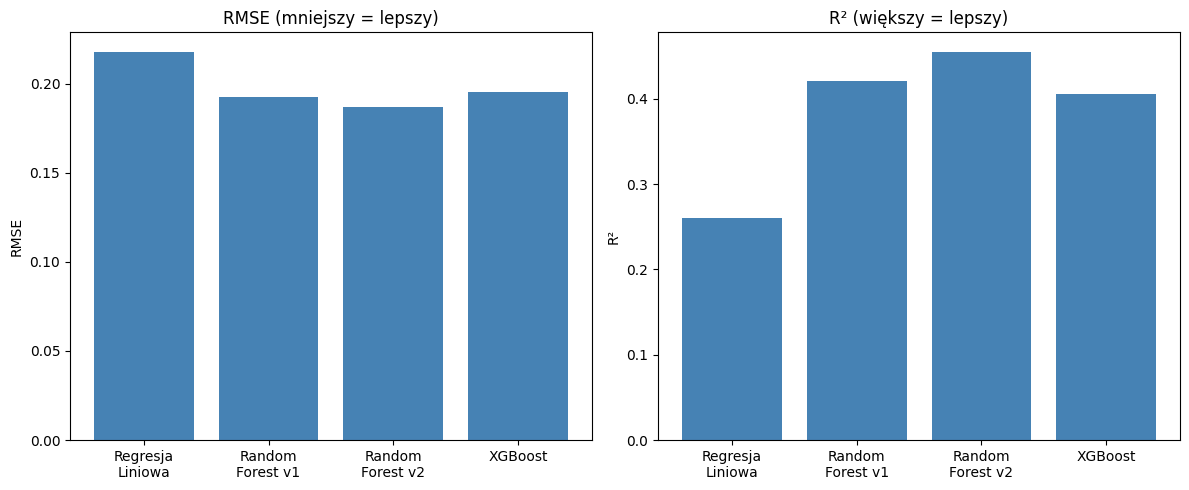

In [23]:
modele = ['Regresja\nLiniowa', 'Random\nForest v1', 'Random\nForest v2', 'XGBoost']
rmse_values = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    np.sqrt(mean_squared_error(y_test_v2, y_pred_v2)),
    np.sqrt(mean_squared_error(y_test_v2, y_pred_xgb))
]
r2_values = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test_v2, y_pred_v2),
    r2_score(y_test_v2, y_pred_xgb)
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(modele, rmse_values, color='steelblue')
ax1.set_title('RMSE (mniejszy = lepszy)')
ax1.set_ylabel('RMSE')

ax2.bar(modele, r2_values, color='steelblue')
ax2.set_title('R² (większy = lepszy)')
ax2.set_ylabel('R²')

plt.tight_layout()
plt.show()

---
## 5. Cross-Validation

Problem z dotychczasową oceną – testowałem na jednym konkretnym splicie 80/20. Mogło mi się trafić "łatwe" 200 filmów.

CV dzieli dane na 5 części, trenuje 5 razy, uśrednia. Bardziej wiarygodne.

In [24]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42, verbosity=0),
    X_v2, y_v2,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

cv_rmse = -cv_scores

print("Cross-Validation (5-fold) dla XGBoost")
print(f"RMSE w każdym foldzie: {[f'{x:.3f}' for x in cv_rmse]}")
print(f"Średnie RMSE: {cv_rmse.mean():.3f} (+/- {cv_rmse.std():.3f})")
print(f"\nPorównanie:")
print(f" Pojedynczy test: {np.sqrt(mean_squared_error(y_test_v2, y_pred_xgb)):.3f}")
print(f" Cross-validation: {cv_rmse.mean():.3f}")

Cross-Validation (5-fold) dla XGBoost
RMSE w każdym foldzie: ['0.441', '0.195', '0.147', '0.169', '0.278']
Średnie RMSE: 0.246 (+/- 0.107)

Porównanie:
 Pojedynczy test: 0.195
 Cross-validation: 0.246


---
## 6. Predykcja na konkretnym filmie

Sprawdzam model na konkretnym filmie z datasetu. Biorę cechy bezpośrednio z danych zamiast wpisywac na sztywno.

Wystarczy zmienić `title` żeby działało dla dowolnego filmu.

In [25]:
title = "The Dark Knight"

row = df[df['Series_Title'] == title].iloc[0]

movie = pd.DataFrame([[
    row['No_of_Votes'],
    row['Meta_score'],
    row['Runtime'],
    row['Gross'],
    row['Released_Year'],
    int(row['Director'] in top_directors)
] + [int(row['Genre'].find(g) != -1) for g in top_genres]], columns=features_v2)

pred = xgb.predict(movie)[0]
print(f"Film: {title}")
print(f"Rzeczywista: {row['IMDB_Rating']}")
print(f"Przewidywana: {pred:.2f}")
print(f"Błąd: {abs(pred - row['IMDB_Rating']):.2f}")

Film: The Dark Knight
Rzeczywista: 9.0
Przewidywana: 8.90
Błąd: 0.10


---
## 7. Analiza błędów

Tabela z kolumnami: rzeczywista ocena, przewidywana, błąd (przewidywana minus rzeczywista, ze znakiem) i błąd_abs do sortowania.

Top 10 największych błędów i top 10 najmniejszych.

In [26]:
results = pd.DataFrame({
    'Tytuł': df.loc[X_test_v2.index, 'Series_Title'].values,
    'Rzeczywista': y_test_v2.values,
    'Przewidywana': y_pred_xgb.round(2),
    'Błąd': (y_pred_xgb - y_test_v2.values).round(2),
    'Błąd_abs': np.abs(y_pred_xgb - y_test_v2.values).round(2)
})

print("10 filmów z NAJWIĘKSZYM błędem")
print(results.sort_values('Błąd_abs', ascending=False).head(10).to_string(index=False))

print("10 filmów z NAJMNIEJSZYM błędem")
print(results.sort_values('Błąd_abs').head(10).to_string(index=False))

10 filmów z NAJWIĘKSZYM błędem
                           Tytuł  Rzeczywista  Przewidywana  Błąd  Błąd_abs
Once Upon a Time... in Hollywood          7.6          8.27  0.67      0.67
                         Seppuku          8.6          7.94 -0.66      0.66
                           Anand          8.4          7.86 -0.54      0.54
                    Vikram Vedha          8.4          7.89 -0.51      0.51
                         Titanic          7.8          8.29  0.49      0.49
          Avengers: Infinity War          8.4          7.95 -0.45      0.45
             The Lives of Others          8.4          7.96 -0.44      0.44
                    Donnie Darko          8.0          8.43  0.43      0.43
          Breakfast at Tiffany's          7.6          8.02  0.42      0.42
       Ayla: The Daughter of War          8.4          7.98 -0.42      0.42
10 filmów z NAJMNIEJSZYM błędem
                                            Tytuł  Rzeczywista  Przewidywana  Błąd  Błąd_abs
        

### Histogram błędów

Czy rozkład jest symetryczny wokół zera? Czy większość blisko zera?

Czerwona pionowa = ideał. Pomarańczowa = średni błąd modelu.

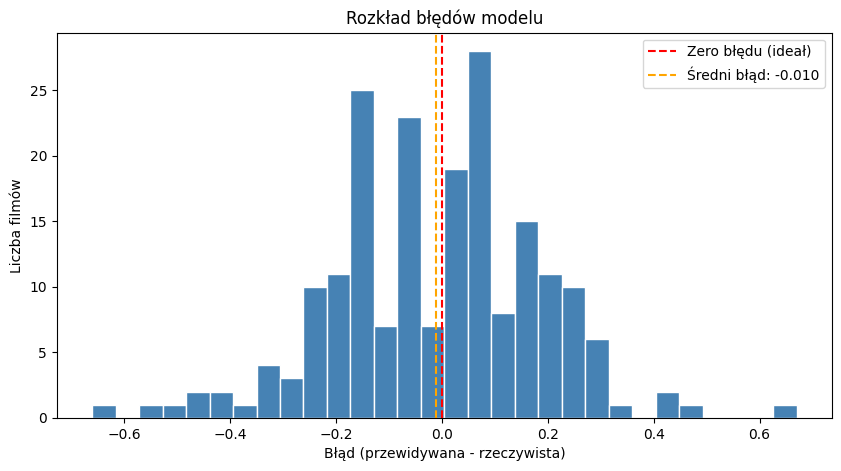

In [27]:
plt.figure(figsize=(10, 5))
plt.hist(results['Błąd'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='Zero błędu (ideał)')
plt.axvline(results['Błąd'].mean(), color='orange', linestyle='--', label=f"Średni błąd: {results['Błąd'].mean():.3f}")
plt.title('Rozkład błędów modelu')
plt.xlabel('Błąd (przewidywana - rzeczywista)')
plt.ylabel('Liczba filmów')
plt.legend()
plt.show()

---
## 8. Hyperparameter Tuning – GridSearchCV

Do tej pory używałem domyślnych parametrów XGBoost. Sprawdzam czy inne kombinacje są lepsze.

3×3×3 = 27 kombinacji × 5 foldów CV = 135 treningów.

`n_jobs=-1` żeby używał wszystkich rdzeni procesora równolegle.

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_v2, y_train_v2)

print(f"\nNajlepsze parametry: {grid_search.best_params_}")
print(f"Najlepsze RMSE (cross_val): {-grid_search.best_score_:.3f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Najlepsze parametry: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Najlepsze RMSE (cross_val): 0.186


### Wynik tuningu

Biorę najlepszy model z GridSearcha i sprawdzam na zbiorze testowym.

In [29]:
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test_v2)

print("Porównanie")
print(f"XGBoost domyślny: RMSE={np.sqrt(mean_squared_error(y_test_v2, y_pred_xgb)):.3f}, R^2={r2_score(y_test_v2, y_pred_xgb):.3f}")
print(f"XGBoost po tuningu: RMSE={np.sqrt(mean_squared_error(y_test_v2, y_pred_best)):.3f}, R^2={r2_score(y_test_v2, y_pred_best):.3f}")

Porównanie
XGBoost domyślny: RMSE=0.195, R^2=0.406
XGBoost po tuningu: RMSE=0.193, R^2=0.420


---
## 9. Learning Curve

Czy więcej danych pomogłoby? Trenuję model na coraz większych kawałkach (10%, 20% ... 100%) i mierzę błąd.

Niebieska linia – błąd treningowy.
Pomarańczowa – błąd walidacyjny.

Jeśli pomarańczowa cały czas opada, więcej danych pomoże. Jeśli płaska od dawna, nic nie da.

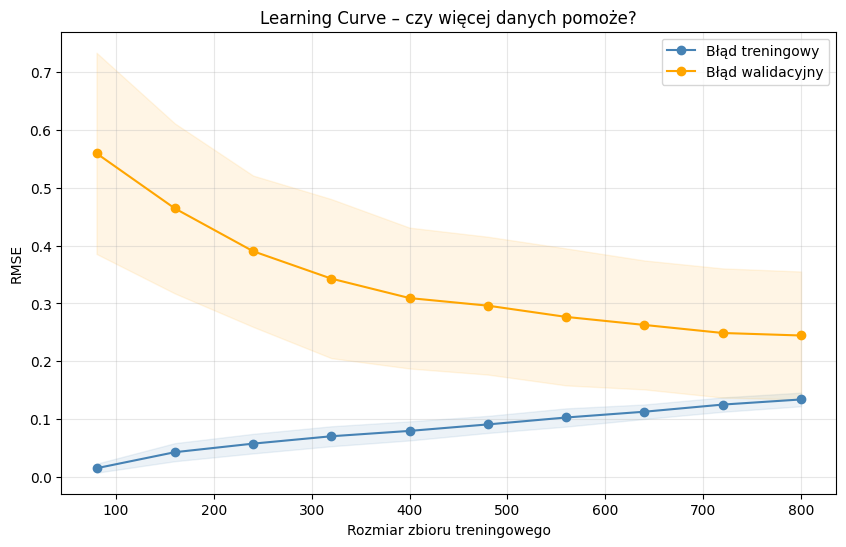

In [30]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    XGBRegressor(**grid_search.best_params_, random_state=42, verbosity=0),
    X_v2, y_v2,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_rmse, 'o-', color='steelblue', label='Błąd treningowy')
plt.plot(train_sizes, val_rmse, 'o-', color='orange', label='Błąd walidacyjny')
plt.fill_between(train_sizes, train_rmse - train_std, train_rmse + train_std, alpha=0.1, color='steelblue')
plt.fill_between(train_sizes, val_rmse - val_std, val_rmse + val_std, alpha=0.1, color='orange')
plt.title('Learning Curve – czy więcej danych pomoże?')
plt.xlabel('Rozmiar zbioru treningowego')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# Część 2 – rozszerzamy dataset

Top 1000 to elita, oceny 7.6-9.3. Wąski zakres. Model nie wie jak wygląda przeciętny film.

Dorzucam IMDB 5000 z Kaggle. Po połączeniu i usunięciu duplikatów ~5500 filmów.

## Krok 1 – wczytuję drugi dataset

Plik `movie_metadata.csv` z Kaggle.
Link: https://www.kaggle.com/datasets/carolzhangdc/imdb-5000-movie-dataset

In [31]:
df2 = pd.read_csv('movie_metadata.csv')
print(f"Rozmiar nowego datasetu: {df2.shape}")
print(f"\nPierwsze kolumny: {df2.columns.tolist()[:10]}")
df2.head(3)

Rozmiar nowego datasetu: (5043, 28)

Pierwsze kolumny: ['color', 'director_name', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'genres']


,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000


## Krok 2 – porównuję kolumny

Oba datasety zawierają to samo ale mają różne nazwy kolumn.

| Top 1000 | IMDB 5000 |
|---|---|
| Series_Title | movie_title |
| Released_Year | title_year |
| Runtime | duration |
| Genre | genres (inny format) |
| IMDB_Rating | imdb_score |
| No_of_Votes | num_voted_users |
| Gross | gross |
| Director | director_name |
| Meta_score | brak |

In [32]:
print("Braki w kluczowych kolumnach:")
klucze = ['movie_title', 'title_year', 'duration', 'genres',
          'imdb_score', 'num_voted_users', 'gross', 'director_name']
print(df2[klucze].isnull().sum())
print(f"\nPrzyklad genres: {df2['genres'].head(3).tolist()}")
print(f"Przyklad title_year: {df2['title_year'].head(3).tolist()}")

Braki w kluczowych kolumnach nowego datasetu:
movie_title          0
title_year         108
duration            15
genres               0
imdb_score           0
num_voted_users      0
gross              884
director_name      104
dtype: int64

Przykład kolumny genres: ['Action|Adventure|Fantasy|Sci-Fi', 'Action|Adventure|Fantasy', 'Action|Adventure|Thriller']
Przykład kolumny title_year: [2009.0, 2007.0, 2015.0]


## Krok 3 – przemianuję kolumny

Wybieram tylko te kolumny które są w obu datasetach i robię rename żeby pasowały do moich.

In [33]:
df2_clean = df2[['movie_title', 'title_year', 'duration', 'genres',
                  'imdb_score', 'num_voted_users', 'gross', 'director_name']].copy()

df2_clean = df2_clean.rename(columns={
    'movie_title':      'Series_Title',
    'title_year':       'Released_Year',
    'duration':         'Runtime',
    'genres':           'Genre',
    'imdb_score':       'IMDB_Rating',
    'num_voted_users':  'No_of_Votes',
    'gross':            'Gross',
    'director_name':    'Director'
})

print(df2_clean.columns.tolist())
df2_clean.head(3)

Kolumny po zmianie nazw:
['Series_Title', 'Released_Year', 'Runtime', 'Genre', 'IMDB_Rating', 'No_of_Votes', 'Gross', 'Director']


,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,No_of_Votes,Gross,Director
0,Avatar,2009.0,178.0,Action|Adventure|Fantasy|Sci-Fi,7.9,886204,760505847.0,James Cameron
1,Pirates of the Caribbean: At World's End,2007.0,169.0,Action|Adventure|Fantasy,7.1,471220,309404152.0,Gore Verbinski
2,Spectre,2015.0,148.0,Action|Adventure|Thriller,6.8,275868,200074175.0,Sam Mendes


## Krok 4 – format Genre

Mój dataset: "Drama, Crime"
Nowy: "Drama|Crime|Thriller"

Zamieniam | na ", " żeby były spójne.

In [34]:
# zamiana | na ', '
df2_clean['Genre'] = df2_clean['Genre'].str.replace('|', ', ', regex=False)

# IMDB 5000 czasem ma spacje na koncu tytulu
df2_clean['Series_Title'] = df2_clean['Series_Title'].str.strip()

print(df2_clean['Genre'].head(5).tolist())

Format Genre po ujednoliceniu:
['Action, Adventure, Fantasy, Sci-Fi', 'Action, Adventure, Fantasy', 'Action, Adventure, Thriller', 'Action, Thriller', 'Documentary']


## Krok 5 – typy danych + brakująca kolumna

`Released_Year` w nowym datasecie jest jako float (2010.0), zamieniam na int.

Meta_score w ogóle nie istnieje w IMDB 5000. Wypełniam wszystkim filmom medianą z Top 1000. Alternatywą byłoby wyrzucenie kolumny. Wolę zachować.

In [35]:
df2_clean['Released_Year'] = pd.to_numeric(df2_clean['Released_Year'], errors='coerce')
df2_clean['Released_Year'] = df2_clean['Released_Year'].fillna(df2_clean['Released_Year'].median()).astype(int)

df2_clean['Gross'] = pd.to_numeric(df2_clean['Gross'], errors='coerce')
df2_clean['Runtime'] = pd.to_numeric(df2_clean['Runtime'], errors='coerce')

# Meta_score nie istnieje w df2 - mediana z Top 1000
meta_median = df['Meta_score'].median()
df2_clean['Meta_score'] = meta_median

print(f"Mediana Meta_score: {meta_median}")
print(df2_clean.dtypes)

Mediana Meta_score z Top 1000: 79.0

Typy danych po czyszczeniu:
Series_Title      object
Released_Year      int64
Runtime          float64
Genre             object
IMDB_Rating      float64
No_of_Votes        int64
Gross            float64
Director          object
Meta_score       float64
dtype: object


## Krok 6 – łączenie datasetów

`pd.concat` skleja DataFramy jeden pod drugim. Wybieram wspólne kolumny żeby struktura była identyczna.

In [36]:
wspolne_kolumny = ['Series_Title', 'Released_Year', 'Runtime', 'Genre',
                   'IMDB_Rating', 'No_of_Votes', 'Gross', 'Director', 'Meta_score']

df_top = df[wspolne_kolumny].copy()
df_new = df2_clean[wspolne_kolumny].copy()

print(f"Top 1000: {df_top.shape[0]}")
print(f"IMDB 5000: {df_new.shape[0]}")

df_combined = pd.concat([df_top, df_new], ignore_index=True)
print(f"Po polaczeniu: {df_combined.shape[0]}")

Top 1000 filmów: 1000 wierszy
IMDB 5000 filmów: 5043 wierszy

Po połączeniu: 6043 wierszy


## Krok 7 – duplikaty

Popularne filmy (Dark Knight, Godfather) są w obu datasetach. Bez usunięcia duplikatów byłyby liczone podwójnie.

`drop_duplicates(subset=['Series_Title', 'Released_Year'])` traktuje duplikat jako ten sam tytuł i rok.
`keep='first'` zostawia pierwszy wpis (z Top 1000, ma lepiej przetworzone dane).

In [37]:
print(f"Przed usunięciem duplikatów: {len(df_combined)} filmów")

duplikaty = df_combined.duplicated(subset=['Series_Title', 'Released_Year'], keep='first')
print(f"Znalezione duplikaty: {duplikaty.sum()}")

df_combined = df_combined.drop_duplicates(subset=['Series_Title', 'Released_Year'], keep='first')
df_combined = df_combined.reset_index(drop=True)

print(f"Po usunięciu duplikatów: {len(df_combined)} filmów")
print(f"\nZysk względem Top 1000: +{len(df_combined) - 1000} filmów")

Przed usunięciem duplikatów: 6043 filmów
Znalezione duplikaty: 550
Po usunięciu duplikatów: 5493 filmów

Zysk względem Top 1000: +4493 filmów


## Krok 8 – weryfikacja

Sprawdzam czy dane mają sens. Średnia ocen powinna spaść bo IMDB 5000 to nie tylko hity.

In [38]:
print("=== WERYFIKACJA POŁĄCZONEGO DATASETU ===\n")
print(f"Liczba filmów: {len(df_combined)}")
print(f"\nBraki danych:")
print(df_combined.isnull().sum())

print(f"\nPorównanie średnich ocen:")
print(f"  Top 1000 (tylko hity):      {df_top['IMDB_Rating'].mean():.2f}")
print(f"  IMDB 5000 (różne filmy):    {df_new['IMDB_Rating'].mean():.2f}")
print(f"  Połączony dataset:          {df_combined['IMDB_Rating'].mean():.2f}")

print(f"\nZakres ocen:")
print(f"  Min: {df_combined['IMDB_Rating'].min()}, Max: {df_combined['IMDB_Rating'].max()}")

=== WERYFIKACJA POŁĄCZONEGO DATASETU ===

Liczba filmów: 5493

Braki danych:
Series_Title       0
Released_Year      0
Runtime           15
Genre              0
IMDB_Rating        0
No_of_Votes        0
Gross            815
Director         102
Meta_score         0
dtype: int64

Porównanie średnich ocen:
  Top 1000 (tylko hity):      7.95
  IMDB 5000 (różne filmy):    6.44
  Połączony dataset:          6.59

Zakres ocen:
  Min: 1.6, Max: 9.5


## Krok 9 – preprocessing na połączonym datasecie

Powtarzam czyszczenie ale teraz na większym zbiorze. Za każdym razem gdy łączysz dane z różnych źródeł, trzeba ponownie sprawdzić braki i typy.

In [39]:
df_combined['Meta_score'] = df_combined['Meta_score'].fillna(df_combined['Meta_score'].median())
df_combined['Gross'] = df_combined['Gross'].fillna(df_combined['Gross'].median())
df_combined['Runtime'] = df_combined['Runtime'].fillna(df_combined['Runtime'].median())
df_combined['Released_Year'] = pd.to_numeric(df_combined['Released_Year'], errors='coerce')
df_combined['Released_Year'] = df_combined['Released_Year'].fillna(df_combined['Released_Year'].median())

df_combined['Runtime'] = df_combined['Runtime'].astype(int)

print(df_combined[['Meta_score', 'Gross', 'Runtime', 'Released_Year']].isnull().sum())

Braki po czyszczeniu:
Meta_score       0
Gross            0
Runtime          0
Released_Year    0
dtype: int64

Gotowe!


## Krok 10 – feature engineering na połączonym

Te same cechy co wcześniej, na większym datasecie.

`top_directors_combined` liczę z całego połączonego zbioru, nie z Top 1000.

In [40]:
top_genres = ['Drama', 'Action', 'Comedy', 'Crime', 'Adventure', 'Biography']
for genre in top_genres:
    df_combined[f'is_{genre}'] = df_combined['Genre'].str.contains(genre, na=False).astype(int)

top_directors_combined = df_combined['Director'].value_counts().head(20).index
df_combined['is_top_director'] = df_combined['Director'].isin(top_directors_combined).astype(int)

print(f"Filmy z top rezyserem: {df_combined['is_top_director'].sum()} ({df_combined['is_top_director'].mean()*100:.1f}%)")
print(df_combined[['Genre'] + [f'is_{g}' for g in top_genres]].head(3).to_string())

Filmy z top reżyserem: 331 (6.0%)

Przykład gatunków po encoding:
                  Genre  is_Drama  is_Action  is_Comedy  is_Crime  is_Adventure  is_Biography
0                 Drama         1          0          0         0             0             0
1          Crime, Drama         1          0          0         1             0             0
2  Action, Crime, Drama         1          1          0         1             0             0


## Krok 11 – trenuję XGBoost na połączonym datasecie

Te same parametry co wcześniej, sprawdzam czy więcej danych = lepszy model.

Porównuję z modelem na Top 1000.

In [41]:
from xgboost import XGBRegressor

features_combined = ['No_of_Votes', 'Meta_score', 'Runtime', 'Gross',
                      'Released_Year', 'is_top_director'] + [f'is_{g}' for g in top_genres]

X_comb = df_combined[features_combined]
y_comb = df_combined['IMDB_Rating']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_comb, y_comb, test_size=0.2, random_state=42
)

xgb_combined = XGBRegressor(n_estimators=100, learning_rate=0.1,
                             max_depth=4, random_state=42, verbosity=0)
xgb_combined.fit(X_train_c, y_train_c)
y_pred_combined = xgb_combined.predict(X_test_c)

from sklearn.metrics import mean_squared_error, r2_score
rmse_comb = np.sqrt(mean_squared_error(y_test_c, y_pred_combined))
r2_comb   = r2_score(y_test_c, y_pred_combined)

# Porównanie z modelem na Top 1000 (xgb trenowany wcześniej w sekcji XGBoost)
rmse_top = np.sqrt(mean_squared_error(y_test_v2, y_pred_xgb))
r2_top   = r2_score(y_test_v2, y_pred_xgb)

print("=== PORÓWNANIE MODELI ===\n")
print(f"XGBoost na Top 1000 filmów:       RMSE={rmse_top:.3f},  R²={r2_top:.3f}")
print(f"XGBoost na {len(df_combined)} filmach:  RMSE={rmse_comb:.3f},  R²={r2_comb:.3f}")
diff_rmse = rmse_comb - rmse_top
diff_r2   = r2_comb - r2_top
print(f"\nRóżnica RMSE: {diff_rmse:+.3f}  ({'lepiej' if diff_rmse < 0 else 'gorzej'})")
print(f"Różnica R²:   {diff_r2:+.3f}  ({'lepiej' if diff_r2 > 0 else 'gorzej'})")


=== PORÓWNANIE MODELI ===

XGBoost na Top 1000 filmów:       RMSE=0.195,  R²=0.406
XGBoost na 5493 filmach:  RMSE=0.781,  R²=0.536

Różnica RMSE: +0.586  (gorzej)
Różnica R²:   +0.130  (lepiej)


## Krok 12 – wykres porównawczy

Słupki RMSE i R² dla obu modeli (Top 1000 vs połączony).

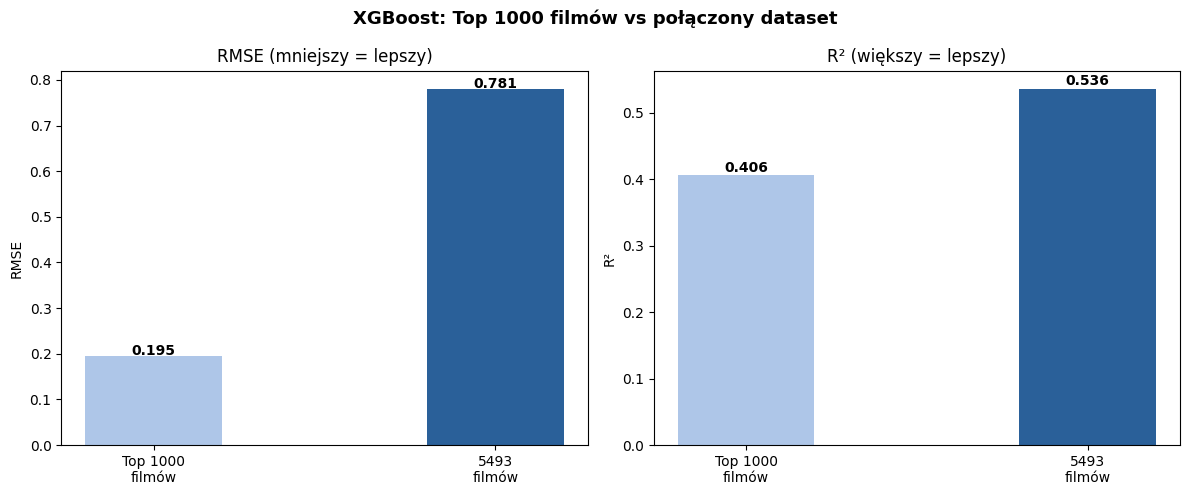

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Wykres 1 – RMSE i R² side by side
modele_labels = [f'Top 1000\nfilmów', f'{len(df_combined)}\nfilmów']
rmse_vals = [np.sqrt(mean_squared_error(y_test_v2, y_pred_xgb)), rmse_comb]
r2_vals = [r2_score(y_test_v2, y_pred_xgb), r2_comb]

x = range(len(modele_labels))
axes[0].bar(x, rmse_vals, color=['#aec6e8', '#2a6099'], width=0.4)
axes[0].set_xticks(x)
axes[0].set_xticklabels(modele_labels)
axes[0].set_title('RMSE (mniejszy = lepszy)')
axes[0].set_ylabel('RMSE')
for i, v in enumerate(rmse_vals):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(x, r2_vals, color=['#aec6e8', '#2a6099'], width=0.4)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modele_labels)
axes[1].set_title('R² (większy = lepszy)')
axes[1].set_ylabel('R²')
for i, v in enumerate(r2_vals):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('XGBoost: Top 1000 filmów vs połączony dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Krok 13 – predykcja dla Dark Knight

Ten sam kod co wcześniej, tylko model trenowany na ~5000 filmach.

In [43]:
# Zmień tytuł na dowolny film z datasetu
title = "The Dark Knight"

row = df_combined[df_combined['Series_Title'] == title].iloc[0]

film_comb = pd.DataFrame([[
    row['No_of_Votes'],
    row['Meta_score'],
    row['Runtime'],
    row['Gross'],
    row['Released_Year'],
    int(row['Director'] in top_directors_combined)
] + [int(row['Genre'].find(g) != -1) for g in top_genres]], columns=features_combined)

# Predykcja nowym modelem (trenowanym na ~5000 filmach)
pred_comb = xgb_combined.predict(film_comb)[0]

# Predykcja starym modelem (trenowanym na Top 1000) – używamy features_v2
film_top = pd.DataFrame([[
    row['No_of_Votes'],
    row['Meta_score'],
    row['Runtime'],
    row['Gross'],
    row['Released_Year'],
    int(row['Director'] in top_directors)
] + [int(row['Genre'].find(g) != -1) for g in top_genres]], columns=features_v2)

pred_top = xgb.predict(film_top)[0]

print(f"Film: {title}")
print(f"Rzeczywista ocena IMDb:                {row['IMDB_Rating']}")
print(f"Przewidywana (model Top 1000):         {pred_top:.2f}  | błąd: {abs(pred_top - row['IMDB_Rating']):.2f}")
print(f"Przewidywana (model {len(df_combined)} filmów):  {pred_comb:.2f}  | błąd: {abs(pred_comb - row['IMDB_Rating']):.2f}")


Film: The Dark Knight
Rzeczywista ocena IMDb:                9.0
Przewidywana (model Top 1000):         8.90  | błąd: 0.10
Przewidywana (model 5493 filmów):  8.61  | błąd: 0.39


## Interpretacja wyników

RMSE wzrosło ale R² się poprawiło. Dziwne na pierwszy rzut oka.

Dlaczego RMSE wzrosło (0.195 → 0.781)?

Top 1000 ma oceny w przedziale 7.6-9.3 (zakres 1.7 punkta). Model który uczy się na takich danych ma małe błędy bo wszystkie odpowiedzi są podobne.

Połączony dataset ma oceny od 3.0 do 9.3. Zakres 6+ punktów, trzy razy szerszy. Model myli się o więcej punktów średnio bo zadanie jest trudniejsze. RMSE rośnie nie dlatego ze model jest gorszy rośnie bo skala problemu jest trudniejsza.

Dlaczego R² wzrosło (0.406 → 0.536)?

R² mierzy jak dobrze model wyjaśnia różnice między filmami. Przy 1000 filmach wszystkie oceny są zblizone, więc nie ma dużo do wyjaśnienia. Przy 5493 filmach jest dużo więcej zmienności. Model wyjaśnia teraz 53.6% tej zmienności.

Dlaczego Dark Knight gorzej w nowym modelu?

Stary model był trenowany tylko na świetnych filmach, jest świetnie skalibrowany dla ocen 7.6-9.3. Nowy model musiał nauczyć się całej skali, dla filmów z górnej półki jest mniej precyzyjny, predykcje są ciągnięte w stronę środka.

Wniosek:

Oba modele są przydatne do różnych rzeczy:
- model Top 1000 lepszy jeśli oceniam tylko filmy z górnej półki
- model 5493 lepszy jeśli oceniam dowolne filmy

In [44]:
!pip install streamlit

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import pickle
import os

os.makedirs('app_files', exist_ok=True)

with open('app_files/model.pkl', 'wb') as f:
    pickle.dump(xgb_combined, f)

required_columns = ['Series_Title', 'Released_Year', 'Runtime', 'Genre', 'IMDB_Rating',
                    'No_of_Votes', 'Gross', 'Director', 'Meta_score', 'is_top_director'] + [f'is_{g}' for g in top_genres]
df_combined[required_columns].to_pickle('app_files/movies.pkl')

with open('app_files/top_directors.pkl', 'wb') as f:
    pickle.dump(list(top_directors_combined), f)

with open('app_files/top_genres.pkl', 'wb') as f:
    pickle.dump(top_genres, f)

with open('app_files/features.pkl', 'wb') as f:
    pickle.dump(features_combined, f)

print("Zapisane pliki:")
for fname in os.listdir('app_files'):
    path = os.path.join('app_files', fname)
    print(f"  {fname}: {os.path.getsize(path)/1024:.1f} KB")

Saved files:
 .ipynb_checkpoints: 0.0 KB
 features.pkl: 0.2 KB
 history.json: 2.5 KB
 model.pkl: 167.9 KB
 movies.pkl: 833.9 KB
 top_directors.pkl: 0.3 KB
 top_genres.pkl: 0.1 KB


---
# Część 4 – plakaty filmów (OMDb API)

Mam działający model i zapisane pliki. Brakuje warstwy wizualnej – dodam plakaty.

OMDb to darmowe API z bazą filmów IMDb. Wysyłam zapytanie po tytule, dostaję slownik z plakatem, opisem fabuły i obsadą.

## Krok 1 – klucz API

Trzeba zarejestrować klucz na OMDb:
1. https://www.omdbapi.com/apikey.aspx
2. Plan FREE (1000 zapytań/dzień)
3. Klucz przyjdzie na maila

Klucz wklejam w komórce ponizej zamiast `TWOJ_KLUCZ_TUTAJ`. Limit darmowego planu to 1000/dzień więc ograniczam pobieranie do popularnych filmów.

In [46]:
import requests

# wklej tutaj swoj klucz OMDB
OMDB_API_KEY = "TWOJ_KLUCZ_TUTAJ"

def fetch_movie_info(title, year=None):
    params = {
        'apikey': OMDB_API_KEY,
        't': title,
        'type': 'movie'
    }
    if year is not None:
        params['y'] = int(year)
    
    try:
        response = requests.get('http://www.omdbapi.com/', params=params, timeout=5)
        data = response.json()
        
        if data.get('Response') == 'True':
            return {
                'poster_url': data.get('Poster') if data.get('Poster') != 'N/A' else None,
                'plot': data.get('Plot'),
                'actors': data.get('Actors'),
                'imdb_id': data.get('imdbID'),
                'imdb_rating': data.get('imdbRating'),
                'awards': data.get('Awards')
            }
        else:
            return None
    except Exception as e:
        print(f"Blad pobierania {title}: {e}")
        return None

# test
test = fetch_movie_info("The Dark Knight", 2008)
if test:
    print("API dziala")
    print(f"Plot: {test['plot'][:200]}...")
    print(f"Poster URL: {test['poster_url']}")
else:
    print("Nie udalo sie pobrac danych. Sprawdz klucz API.")

API działa!
Plot: When a menace known as the Joker wreaks havoc and chaos on the people of Gotham, Batman, James Gordon and Harvey Dent must work together to put an end to the madness....
Poster URL: https://m.media-amazon.com/images/M/MV5BMTMxNTMwODM0NF5BMl5BanBnXkFtZTcwODAyMTk2Mw@@._V1_QL75_UX380_CR0,0,380,562_.jpg
Nagrody: Won 2 Oscars. 163 wins & 165 nominations total


## Krok 2 – 6 top filmów z plakatami

Test – 6 filmów z największą przewidywaną oceną, pokazane w siatce 3x2.

`IPython.display.HTML` wyświetla dowolny HTML w komórce.

In [47]:
from IPython.display import HTML, display

if 'Przewidywana_ocena' not in df_combined.columns:
    X_all = df_combined[features_combined]
    df_combined['Przewidywana_ocena'] = xgb_combined.predict(X_all).round(2)

top_6 = (df_combined[df_combined['No_of_Votes'] >= 100000]
         .sort_values('Przewidywana_ocena', ascending=False)
         .head(6))

print("Pobieram plakaty...\n")

filmy_z_plakatami = []
for _, film in top_6.iterrows():
    info = fetch_movie_info(film['Series_Title'], film['Released_Year'])
    filmy_z_plakatami.append({
        'title': film['Series_Title'],
        'year': int(film['Released_Year']),
        'rating': film['IMDB_Rating'],
        'predicted': film['Przewidywana_ocena'],
        'director': film['Director'],
        'poster': info['poster_url'] if info else None,
        'plot': info['plot'] if info else "Brak opisu"
    })
    print(f"  ok {film['Series_Title']}")

html = '<div style="display: grid; grid-template-columns: repeat(3, 1fr); gap: 20px; font-family: sans-serif;">'
for f in filmy_z_plakatami:
    poster_tag = (
        f'<img src="{f["poster"]}" style="width: 100%; border-radius: 8px;">'
        if f['poster']
        else '<div style="background:#eee; padding: 60px; text-align:center; border-radius: 8px;">Brak plakatu</div>'
    )
    html += f'''
    <div style="border: 1px solid #ddd; border-radius: 8px; padding: 12px; background: #fafafa;">
        {poster_tag}
        <h3 style="margin: 10px 0 5px 0;">{f["title"]} ({f["year"]})</h3>
        <p style="margin: 2px 0; color: #666;">{f["director"]}</p>
        <p style="margin: 2px 0;">IMDb: <b>{f["rating"]}</b> | Model: <b>{f["predicted"]}</b></p>
    </div>
    '''
html += '</div>'

display(HTML(html))

Pobieram plakaty z OMDb API (6 zapytań)...

  ✓ The Godfather
  ✓ The Godfather: Part II
  ✓ Schindler's List
  ✓ The Shawshank Redemption
  ✓ Il buono, il brutto, il cattivo
  ✓ Pulp Fiction


## Krok 3 – pobieranie plakatów dla całego datasetu

Pobieram plakaty dla wszystkich popularnych filmów (min 50k głosów) i nadpisuję `movies.pkl` żeby Streamlit miał z czego korzystać.

Limit darmowego OMDb to 1000/dzień, dlatego filtr 50k głosów.

`time.sleep(0.1)` między requestami – rate limiting, zeby API mnie nie zablokowało.

In [48]:
from tqdm.notebook import tqdm
import time

popular_movies = df_combined[df_combined['No_of_Votes'] >= 150000].copy()
print(f"Filmow do pobrania: {len(popular_movies)}")
print(f"Szacowany czas: ~{len(popular_movies) * 0.3 / 60:.1f} min\n")

posters = {}
plots = {}

for idx, film in tqdm(popular_movies.iterrows(), total=len(popular_movies)):
    info = fetch_movie_info(film['Series_Title'], film['Released_Year'])
    if info:
        posters[idx] = info['poster_url']
        plots[idx] = info['plot']
    else:
        posters[idx] = None
        plots[idx] = None
    time.sleep(0.1)

df_combined.loc[popular_movies.index, 'Poster_URL'] = pd.Series(posters)
df_combined.loc[popular_movies.index, 'Plot'] = pd.Series(plots)

udane = df_combined['Poster_URL'].notna().sum()
print(f"\nPobrano plakatow: {udane}/{len(popular_movies)} ({udane/len(popular_movies)*100:.1f}%)")

required_columns = ['Series_Title', 'Released_Year', 'Runtime', 'Genre',
                    'IMDB_Rating', 'No_of_Votes', 'Gross', 'Director',
                    'Meta_score', 'is_top_director', 'Poster_URL', 'Plot'] + [f'is_{g}' for g in top_genres]
df_combined[required_columns].to_pickle('app_files/movies.pkl')

print("Zaktualizowano app_files/movies.pkl")

Filmów do pobrania: 947
Szacowany czas: ~4.7 min



  0%|          | 0/947 [00:00<?, ?it/s]


✓ Pobrano plakatów: 875/947 (92.4%)

✓ Zaktualizowano app_files/movies.pkl
  Streamlit będzie teraz używał prawdziwych plakatów zamiast placeholderów!


---
# Część 5 – aplikacja Streamlit

Cały kod aplikacji `app.py`. Ta komórka nie uruchomi się w Jupyterze (Streamlit wymaga `streamlit run app.py` z terminala).

Co robi aplikacja:
- ładuje model i dataset z plików .pkl
- pokazuje sidebar z filtrami (gatunki, dekada, długość filmu, min głosów, Metacritic)
- po kliknięciu "Znajdz filmy" filtruje dataset i sortuje po przewidywanej ocenie
- wyświetla top 10 z plakatami i linkami do YouTube/IMDb
- zapisuje historię ostatnich 20 wyszukiwań

### Kluczowe rzeczy w kodzie

Cache: `@st.cache_resource` dla modelu, `@st.cache_data` dla danych. Streamlit przy każdej interakcji uruchamia cały plik od nowa, więc bez cache model ładowałby się za każdym razem.

Filtrowanie: każdy filtr zawęża wczesniejszy wynik. Logika AND, film musi spełniać wszystkie filtry naraz.

Predykcja: filmy które przeszły filtry są scorowane modelem XGBoost, sortowane po przewidywanej ocenie.

Historia: zapisuję 20 ostatnich wyszukiwań do JSON-a w `app_files/history.json`.

In [49]:
import streamlit as st
import pandas as pd
import pickle
import json
import os
from datetime import datetime
from urllib.parse import quote_plus

st.set_page_config(
    page_title="Rekomendacje filmów",
    page_icon="🎬",
    layout="wide"
)

# ========== ŚCIEŻKI ==========
HISTORY_FILE = 'app_files/history.json'

# ========== ŁADOWANIE MODELU I DANYCH ==========

@st.cache_resource
def load_model():
    with open('app_files/model.pkl', 'rb') as f:
        return pickle.load(f)

@st.cache_data
def load_movies():
    return pd.read_pickle('app_files/movies.pkl')

@st.cache_data
def load_artifacts():
    with open('app_files/top_directors.pkl', 'rb') as f:
        top_directors = pickle.load(f)
    with open('app_files/top_genres.pkl', 'rb') as f:
        top_genres = pickle.load(f)
    with open('app_files/features.pkl', 'rb') as f:
        features = pickle.load(f)
    return top_directors, top_genres, features

model = load_model()
df = load_movies()
top_directors, top_genres, features = load_artifacts()

# ========== HISTORIA WYSZUKIWAŃ ==========

def load_history():
    if not os.path.exists(HISTORY_FILE):
        return []
    try:
        with open(HISTORY_FILE, 'r', encoding='utf-8') as f:
            return json.load(f)
    except (json.JSONDecodeError, FileNotFoundError):
        return []

def save_to_history(entry):
    history = load_history()
    history.insert(0, entry)
    history = history[:20]
    with open(HISTORY_FILE, 'w', encoding='utf-8') as f:
        json.dump(history, f, ensure_ascii=False, indent=2)

# ========== POMOCNICZE FUNKCJE ==========

def youtube_search_url(title, year):
    query = quote_plus(f"{title} {int(year)} trailer")
    return f"https://www.youtube.com/results?search_query={query}"

def imdb_search_url(title):
    query = quote_plus(title)
    return f"https://www.imdb.com/find/?q={query}"

def poster_placeholder(title):
    clean_title = quote_plus(title[:40])
    return f"https://placehold.co/200x300/2a6099/white?text={clean_title}&font=roboto"

def get_poster_url(film):
    """Zwraca prawdziwy plakat z OMDb jeśli jest, fallback na placeholder."""
    if 'Poster_URL' in film and pd.notna(film.get('Poster_URL')):
        return film['Poster_URL']
    return poster_placeholder(film['Series_Title'])

# ========== NAGŁÓWEK ==========

st.title("🎬 System rekomendacji filmów")
st.write(f"Baza **{len(df)} filmów**. Model: XGBoost z R² = 0.54")

# ========== ZAKŁADKI ==========

tab_rekomendacje, tab_historia = st.tabs(["🎯 Rekomendacje", "📜 Historia wyszukiwań"])

# ========== SIDEBAR Z FILTRAMI ==========

st.sidebar.header("🎯 Twoje preferencje")
st.sidebar.write("Powiedz nam czego szukasz:")

wybrane_gatunki = st.sidebar.multiselect(
    "Ulubione gatunki:",
    options=top_genres,
    default=['Drama'],
    help="Wybierz jeden lub więcej gatunków"
)

# Dekada - shortcut albo własny zakres
min_rok = int(df['Released_Year'].min())
max_rok = int(df['Released_Year'].max())

dekada_preset = st.sidebar.selectbox(
    "Szybki wybór dekady:",
    options=['Dowolna', 'Lata 70.', 'Lata 80.', 'Lata 90.', 'Lata 2000.', 'Lata 2010.', 'Lata 2020.'],
    index=0
)

dekada_mapping = {
    'Lata 70.': (1970, 1979),
    'Lata 80.': (1980, 1989),
    'Lata 90.': (1990, 1999),
    'Lata 2000.': (2000, 2009),
    'Lata 2010.': (2010, 2019),
    'Lata 2020.': (2020, max_rok),
}

if dekada_preset == 'Dowolna':
    zakres_lat = st.sidebar.slider(
        "Lub ustaw własny zakres lat:",
        min_value=min_rok,
        max_value=max_rok,
        value=(2000, max_rok)
    )
else:
    zakres_lat = dekada_mapping[dekada_preset]
    st.sidebar.caption(f"Zakres: {zakres_lat[0]}–{zakres_lat[1]}")

# Długość filmu jako zakres
zakres_runtime = st.sidebar.slider(
    "Długość filmu (minuty):",
    min_value=60,
    max_value=240,
    value=(90, 180),
    step=15,
    help="Od jakiej do jakiej długości"
)

tylko_topowi_rezyserzy = st.sidebar.checkbox(
    "Tylko znani reżyserzy",
    value=False,
    help="Filmy wyreżyserowane przez top 20 reżyserów w bazie"
)

min_glosow = st.sidebar.slider(
    "Minimalna liczba głosów IMDb:",
    min_value=0,
    max_value=500000,
    value=50000,
    step=10000,
    help="Więcej głosów = film bardziej znany"
)

min_metacritic = st.sidebar.slider(
    "Minimalny Metacritic Score:",
    min_value=0,
    max_value=100,
    value=0,
    step=5,
    help="0 = bez filtra. Metacritic to oceny krytyków"
)

liczba_wynikow = st.sidebar.slider(
    "Ile filmów pokazać:",
    min_value=5,
    max_value=30,
    value=10
)

st.sidebar.markdown("---")
szukaj = st.sidebar.button("🔍 Znajdź filmy", type="primary", use_container_width=True)

# ========== ZAKŁADKA: REKOMENDACJE ==========

with tab_rekomendacje:
    if szukaj:
        if not wybrane_gatunki:
            st.warning("⚠️ Wybierz przynajmniej jeden gatunek w panelu bocznym!")
            st.stop()

        # FILTROWANIE
        with st.spinner("Szukam filmów pasujących do Twoich preferencji..."):
            filtered = df.copy()

            maska_gatunku = pd.Series([False] * len(filtered), index=filtered.index)
            for genre in wybrane_gatunki:
                maska_gatunku = maska_gatunku | (filtered[f'is_{genre}'] == 1)
            filtered = filtered[maska_gatunku]

            filtered = filtered[
                (filtered['Released_Year'] >= zakres_lat[0]) &
                (filtered['Released_Year'] <= zakres_lat[1])
            ]

            filtered = filtered[
                (filtered['Runtime'] >= zakres_runtime[0]) &
                (filtered['Runtime'] <= zakres_runtime[1])
            ]

            if tylko_topowi_rezyserzy:
                filtered = filtered[filtered['is_top_director'] == 1]

            filtered = filtered[filtered['No_of_Votes'] >= min_glosow]

            if min_metacritic > 0:
                filtered = filtered[filtered['Meta_score'] >= min_metacritic]

            if len(filtered) == 0:
                st.error("❌ Żaden film nie pasuje do Twoich filtrów. Rozluźnij kryteria.")
                st.stop()

        # PREDYKCJA MODELEM
        with st.spinner(f"Znaleziono {len(filtered)} pasujących filmów. Model ocenia..."):
            X_filtered = filtered[features]
            filtered = filtered.copy()
            filtered['Przewidywana_ocena'] = model.predict(X_filtered).round(2)

        top_filmy = filtered.sort_values('Przewidywana_ocena', ascending=False).head(liczba_wynikow)

        # ZAPIS DO HISTORII
        entry = {
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M'),
            'gatunki': wybrane_gatunki,
            'lata': f"{zakres_lat[0]}-{zakres_lat[1]}",
            'dlugosc': f"{zakres_runtime[0]}-{zakres_runtime[1]} min",
            'min_glosow': min_glosow,
            'min_metacritic': min_metacritic,
            'topowi_rezyserzy': tylko_topowi_rezyserzy,
            'liczba_wynikow': len(top_filmy),
            'top_3': top_filmy['Series_Title'].head(3).tolist()
        }
        save_to_history(entry)

        # WYŚWIETLENIE
        st.success(f"✅ Znalazłem {len(top_filmy)} filmów dla Ciebie!")

        col1, col2, col3, col4 = st.columns(4)
        col1.metric("Pasujące filmy", len(filtered))
        col2.metric("Średnia IMDb w wynikach", f"{top_filmy['IMDB_Rating'].mean():.2f}")
        col3.metric("Najwyższa predykcja", f"{top_filmy['Przewidywana_ocena'].max():.2f}")
        col4.metric("Średni Metacritic", f"{top_filmy['Meta_score'].mean():.0f}")

        st.markdown("---")

        # Lista filmów z plakatami
        for idx, (_, film) in enumerate(top_filmy.iterrows(), start=1):
            with st.container():
                kol_plakat, kol_info, kol_oceny = st.columns([1.5, 4, 2])

                with kol_plakat:
                    st.image(get_poster_url(film), width=180)

                with kol_info:
                    st.markdown(f"### #{idx}. {film['Series_Title']} ({int(film['Released_Year'])})")
                    st.write(f"🎭 **Gatunek:** {film['Genre']}")
                    st.write(f"🎬 **Reżyser:** {film['Director']}")
                    st.write(f"⏱️ **Długość:** {int(film['Runtime'])} min  |  👥 **Głosy:** {int(film['No_of_Votes']):,}")
                    if pd.notna(film['Meta_score']):
                        st.write(f"📊 **Metacritic:** {int(film['Meta_score'])}/100")

                    # Plot z OMDb jeśli jest
                    if 'Plot' in film and pd.notna(film.get('Plot')):
                        st.caption(f"📖 {film['Plot']}")

                    # Linki zewnętrzne
                    yt_url = youtube_search_url(film['Series_Title'], film['Released_Year'])
                    imdb_url = imdb_search_url(film['Series_Title'])
                    st.markdown(
                        f"🎞️ [Zobacz trailer na YouTube]({yt_url}) &nbsp;•&nbsp; "
                        f"🎬 [Znajdź na IMDb]({imdb_url})"
                    )

                with kol_oceny:
                    st.metric("Ocena IMDb", film['IMDB_Rating'])
                    st.metric("Predykcja modelu", film['Przewidywana_ocena'])

                st.markdown("---")

    else:
        st.info("👈 Ustaw preferencje w panelu bocznym i kliknij **Znajdź filmy**")

        with st.expander("Zobacz przykładowe filmy z bazy"):
            st.dataframe(df[['Series_Title', 'Released_Year', 'Genre', 'IMDB_Rating', 'Director']].sample(10))

# ========== ZAKŁADKA: HISTORIA ==========

with tab_historia:
    st.header("📜 Historia ostatnich wyszukiwań")
    st.caption("Twoje ostatnie 20 wyszukiwań (zapisywane automatycznie)")

    history = load_history()

    if not history:
        st.info("Nie ma jeszcze żadnej historii. Przeprowadź pierwsze wyszukiwanie w zakładce Rekomendacje.")
    else:
        col_a, col_b = st.columns([5, 1])
        with col_b:
            if st.button("🗑️ Wyczyść historię", use_container_width=True):
                if os.path.exists(HISTORY_FILE):
                    os.remove(HISTORY_FILE)
                st.rerun()

        st.markdown("---")

        for i, entry in enumerate(history, start=1):
            with st.expander(f"#{i} — {entry['timestamp']} — {', '.join(entry['gatunki'])}", expanded=(i == 1)):
                c1, c2 = st.columns(2)
                with c1:
                    st.write(f"**Gatunki:** {', '.join(entry['gatunki'])}")
                    st.write(f"**Lata:** {entry['lata']}")
                    st.write(f"**Długość:** {entry['dlugosc']}")
                with c2:
                    st.write(f"**Min. głosów:** {entry['min_glosow']:,}")
                    st.write(f"**Min. Metacritic:** {entry['min_metacritic']}")
                    st.write(f"**Tylko top reżyserzy:** {'Tak' if entry['topowi_rezyserzy'] else 'Nie'}")

                st.write(f"**Top 3 filmy z tego wyszukiwania:**")
                for j, title in enumerate(entry['top_3'], start=1):
                    st.write(f"  {j}. {title}")


2026-05-05 20:12:28.277 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 20:12:28.278 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-05 20:12:28.279 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-05 20:12:28.281 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 20:12:28.837 
  command:

    streamlit run C:\Users\korwi\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-05 20:12:28.838 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 20:12:28.839 Thread 'MainThread': missing ScriptRunContext! This warnin

---
# Część 6 – Optuna

Robiłem juz tuning przez GridSearchCV. Działa, ale ma wady:
- ograniczenie do listy wartości (jeśli najlepsze n_estimators=263, GridSearch tego nie znajdzie bo sprawdzał tylko 50, 100, 200)
- wykładnicza eksplozja kombinacji
- marnuje czas na słabe kombinacje

Optuna sprawdza zakresy ciągłe i mądrzej dobiera wartości – po kilku losowych próbach kieruje się tam gdzie wyniki są obiecujące. To Bayesian optimization.

Zalety:
- zakresy zamiast list (50-300 zamiast [50, 100, 200])
- stała liczba prób niezależnie od liczby parametrów
- wbudowane wykresy importance

In [54]:
import sys
!{sys.executable} -m pip install optuna


   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   ---------------------------------------- 2/2 [optuna]




[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\korwi\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


## Krok 1 – funkcja objective

To przepis dla Optuny. Mówi: jak chcesz coś sprawdzić, zrób tak.

Funkcja przyjmuje `trial` – obiekt który Optuna sama tworzy przy każdej próbie. Przez `trial` Optuna wybiera konkretne wartości parametrów.

`trial.suggest_int('n_estimators', 50, 300)` zwraca liczbę całkowitą 50-300.
`trial.suggest_float('learning_rate', 0.01, 0.3, log=True)` zwraca float w skali logarytmicznej.

Skala log dla learning_rate bo różnica 0.01 vs 0.05 jest dużo ważniejsza niż 0.25 vs 0.3.

Na końcu zwracam minus RMSE bo sklearn taka konwencja, odwracam zeby Optuna miała dodatnie wartości.

In [55]:
import optuna
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1),
    }

    model = XGBRegressor(**params, random_state=42, verbosity=0)
    scores = cross_val_score(model, X_train_c, y_train_c, cv=5, scoring='neg_root_mean_squared_error')
    
    return -scores.mean()

## Krok 2 – uruchomienie

`create_study(direction='minimize')` tworzy kontener na próby, minimize bo szukam najmniejszego RMSE.

`optimize(objective, n_trials=50)` uruchamia 50 prób. Pierwsze losowe, potem coraz mądrzejsze. Każda próba wywołuje funkcję objective, dostaje RMSE, Optuna zapisuje wynik i wybiera kolejne parametry.

Wynik to najlepsze RMSE i parametry które do niego doprowadziły.

In [56]:
study = optuna.create_study(direction='minimize')

print("Optuna szuka najlepszych parametrów (50 prób)...")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nNajlepsze RMSE: {study.best_value:.4f}")
print(f"Najlepsze parametry:")
for k, v in study.best_params.items():
    print(f" {k}: {v}")

Optuna szuka najlepszych parametrów (50 prób)...


  0%|          | 0/50 [00:00<?, ?it/s]


Najlepsze RMSE: 0.7766
Najlepsze parametry:
 n_estimators: 263
 max_depth: 5
 learning_rate: 0.02541385694859586
 subsample: 0.7155094625147279
 colsample_bytree: 0.9890582458983794


## Krok 3 – porównanie z domyślnym XGBoost

Sprawdzam czy parametry znalezione przez Optunę są lepsze od domyślnych (n_estimators=100, learning_rate=0.1, max_depth=4).

Poprawa zwykle mała bo domyślne parametry XGBoost są dobrze dobrane. W moim przypadku poprawa rzędu 0.007 RMSE, ale w prawdziwych projektach (np. finanse) 1% poprawy może oznaczać sporo.

`**study.best_params` rozpakowuje słownik do argumentów funkcji.

In [58]:
default_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1,
                             max_depth=4, random_state=42, verbosity=0)
default_scores = cross_val_score(default_xgb, X_train_c, y_train_c, cv=5, scoring='neg_root_mean_squared_error')
default_rmse = -default_scores.mean()

print(f"XGBoost domyślny RMSE = {default_rmse:.4f}")
print(f"XGBoost po Optunie RMSE = {study.best_value:.4f}")
print(default_rmse - study.best_value)

xgb_optimized = XGBRegressor(**study.best_params, random_bstate=42, verbosity=0)
xgb_optimized.fit(X_train_c, y_train_c)

XGBoost domyślny RMSE = 0.7832
XGBoost po Optunie RMSE = 0.7766
0.00656450669511921


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9890582458983794
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Krok 4 – wykresy Optuny

Dwa wbudowane wykresy.

Postęp w czasie: 50 niebieskich kropek (każda próba) + czerwona linia (najlepszy dotychczas wynik). Czerwona z definicji tylko opada.

Importance hiperparametrów: który parametr ma największy wpływ na wynik. U mnie:
- learning_rate ~0,53
- subsample ~0,30
- colsample_bytree ~0,11
- n_estimators ~0,04
- max_depth ~0,03

Ciekawa rzecz – n_estimators i max_depth prawie nie mają znaczenia. A to są parametry które najczęściej tunuje się ręcznie.

C:\Users\korwi\AppData\Local\Temp\ipykernel_34848\754907558.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


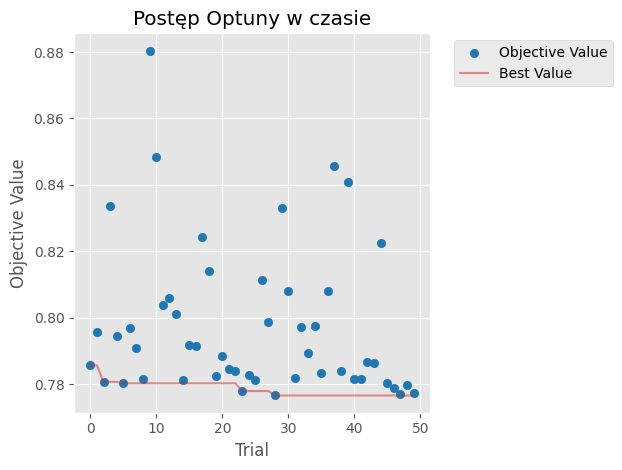

C:\Users\korwi\AppData\Local\Temp\ipykernel_34848\754907558.py:8: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


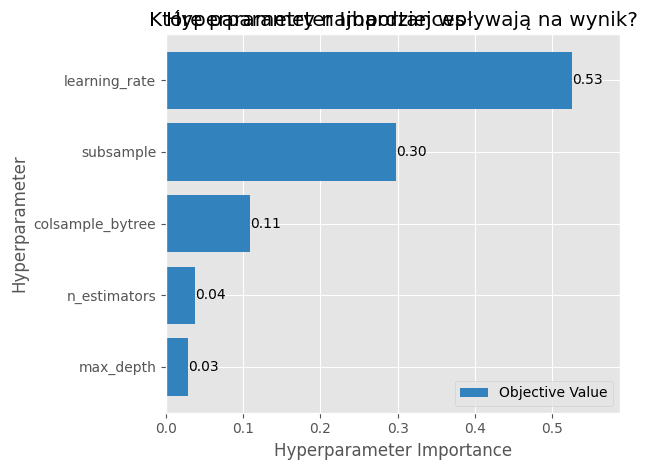

In [63]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

plot_optimization_history(study)
plt.title("Postęp Optuny w czasie")
plt.tight_layout()
plt.show()

plot_param_importances(study)
plt.title("Które parametry najbardziej wpływają na wynik?")
plt.tight_layout()
plt.show()

## Krok 5 – aktualizacja głównego modelu

Zastępuję `xgb_combined` wytunowanym `xgb_optimized`. Od tej linii wszystkie kolejne operacje (SHAP, predykcje) używają wytunowanego modelu.

In [65]:
xgb_combined = xgb_optimized

---
# Część 7 – SHAP

Feature Importance mówi że "No_of_Votes jest ważne ogólnie". Ale dla konkretnego filmu, co najbardziej wpłynęło na predykcję? W jaką stronę? O ile dokładnie?

SHAP to ogarnia. Dla każdego filmu rozkłada predykcję na wpływy poszczególnych cech.

Nazwa: SHapley Additive exPlanations. Od matematyka Shapleya który wymyslił sposób żeby sprawiedliwie podzielić zasługi w grupie. SHAP używa tej samej matematyki dla cech w predykcji.

Praktyczne zastosowania:
- klient pyta czemu model dał taką predykcję, mam odpowiedź
- diagnoza modelu, widać gdzie i dlaczego model się myli
- wymóg prawny w finansach/medycynie, modele muszą być wyjaśnialne

In [64]:
import sys
!{sys.executable} -m pip install shap


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\korwi\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


## Krok 2 – tworzę explainer i liczę SHAP values

`shap.TreeExplainer` to specjalna wersja dla modeli drzewiastych (XGBoost, RF). Bardzo szybka.

`shap_values` to macierz – dla każdego filmu, dla każdej cechy, wartość mówiąca o ile ta cecha zmieniła predykcję dla tego konkretnego filmu.

`expected_value` to wartość bazowa, czyli średnia predykcja modelu na zbiorze treningowym. To punkt startowy. U mnie ~6.586.

Dla każdego filmu zachodzi: suma SHAP values + wartość bazowa = predykcja modelu.

To matematyczna gwarancja SHAP. SHAP nie zmienia predykcji, tylko rozkłada ją na czynniki.

In [68]:
import shap

explainer = shap.TreeExplainer(xgb_combined)
shap_values = explainer.shap_values(X_test_c)

print(f"Kształt SHAP values: {shap_values.shape}")
print(f"{shap_values.shape[0]} filmów x {shap_values.shape[1]} cech")
print(f"\nWartość bazowa: {explainer.expected_value:.3f}")
print(f"\nDla pierwszego filmu:")
print(f"Suma wpływów + abzowa = predykcja")
print(f"{shap_values[0].sum():.3f} + {explainer.expected_value:.3f} = {shap_values[0].sum() + explainer.expected_value:.3f}")

Kształt SHAP values: (1099, 12)
1099 filmów x 12 cech

Wartość bazowa: 6.586

Dla pierwszego filmu:
Suma wpływów + abzowa = predykcja
-0.034 + 6.586 = 6.552


## Krok 3 – summary plot

Każdy punkt = jeden film. Każda cecha to osobna chmurka punktów.

- pozycja w pionie – która cecha (od najwazniejszej u góry)
- pozycja w poziomie – jak ta cecha wpłynęła (lewo = obnizyła, prawo = podbiła)
- kolor – wartość samej cechy (czerwony = wysoka, niebieski = niska)

Co odczytuję z wykresu:

No_of_Votes: niebieskie po lewej, czerwone po prawej. Mało głosów obniża predykcję, dużo głosów podbija. Wpływ ogromny, kropki rozchodzą się od -1.5 do +1.5.

is_Drama: dwa skupiska. Bycie dramatem podbija ocenę o ~0.2-0.3.

Released_Year: czerwone po lewej, niebieskie po prawej. Stare filmy podbijają, nowe obnizają. Stare filmy w datasecie to klasyki które przetrwały próbę czasu.

is_Action: czerwone (filmy akcji) po lewej. Bycie akcji obniża predykcję.

is_top_director na samym dole – prawie zero wpływu. Inne cechy "kanibalizują" tę informację.

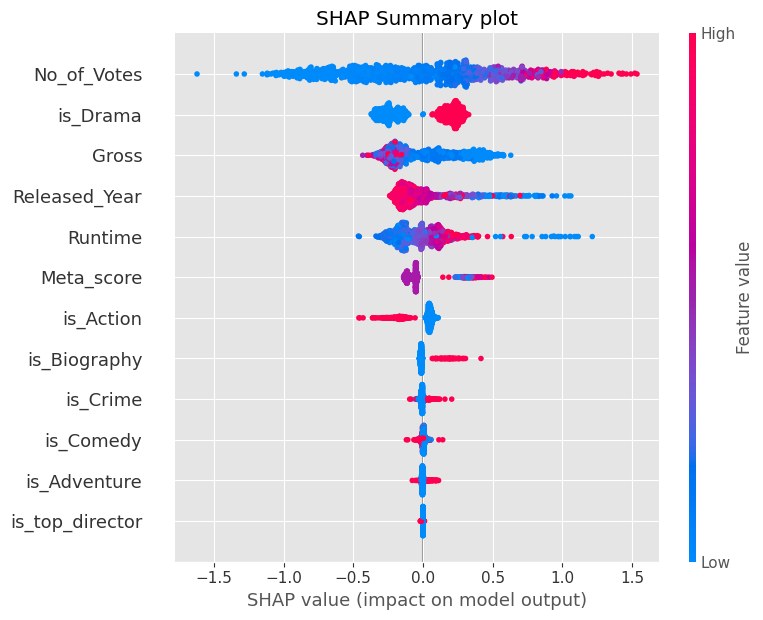

In [69]:
shap.summary_plot(shap_values, X_test_c, show=False)
plt.title("SHAP Summary plot")
plt.tight_layout()
plt.show()

## Krok 4 – waterfall plot

Wyjaśnienie predykcji dla jednego konkretnego filmu.

Czytamy od dołu do góry.

Na dole wartość bazowa (średnia predykcja modelu).
Każda strzałka pokazuje jak konkretna cecha zmieniła predykcję:
- czerwona w prawo – podbiła
- niebieska w lewo – obnizyła
- długość = siła wpływu

Na górze finalna predykcja modelu.

Każda strzałka ma podpis: nazwa cechy + jej wartość. Np. dla Inception:
- No_of_Votes = 2,067,042 → +1.52
- Meta_score = 74 → +0.41
- Gross = 292M → -0.18 (wysokie przychody obnizają, model traktuje to jako sygnał blockbustera)
- Released_Year = 2010 → -0.15

Suma strzałek + bazowa = predykcja na górze.

Dla Inception predykcja 8.08 vs rzeczywista 8.8. Model myli się o 0.72, prawdopodobnie dlatego ze Inception to nietypowy blockbuster - ma wysokie Gross i jednoczesnie wysokie oceny, co jest rzadkie w datasecie.

Można zmienić `title` na inny film z datasetu.

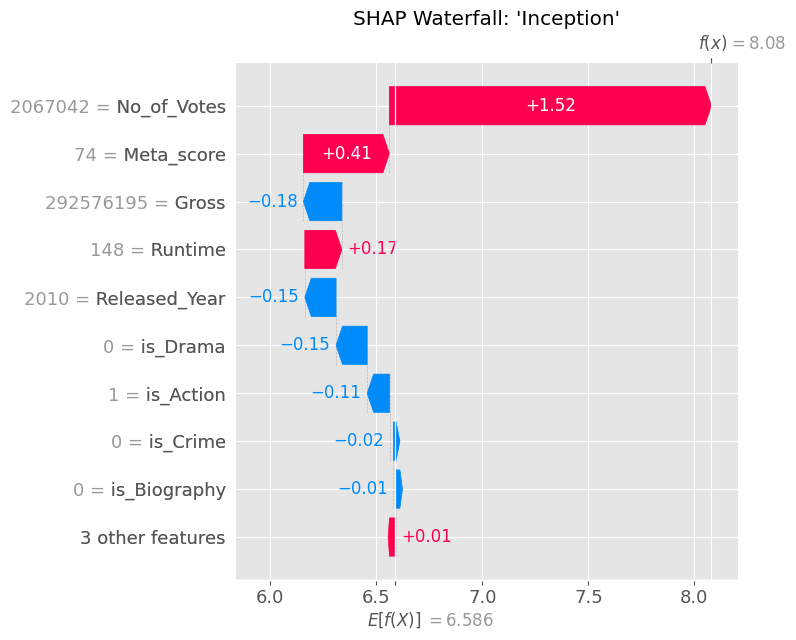

Rzeczywista ocena: 8.8
Predykcja modelu: 8.08


In [71]:
title = "Inception"
film_index = df_combined[df_combined['Series_Title'] == title].index[0]

X_all = df_combined[features_combined]
shap_values_film = explainer.shap_values(X_all.loc[[film_index]])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_film[0],
        base_values=explainer.expected_value,
        data=X_all.loc[film_index].values,
        feature_names=features_combined
    ),
    show=False
)
plt.title(f"SHAP Waterfall: '{title}'")
plt.tight_layout()
plt.show()

predykcja = xgb_combined.predict(X_all.loc[[film_index]])[0]
rzeczywista = df_combined.loc[film_index, 'IMDB_Rating']
print(f"Rzeczywista ocena: {rzeczywista}")
print(f"Predykcja modelu: {predykcja:.2f}")